# Tugas Proyek IF3211 - Domain-Specific Computation
## Deteksi Transisi Respirasi Aerobik-Anaerobik Berdasarkan Respiratory Exchange Ratio (RER) Menggunakan Arsitektur Long Short-Term Memory (LSTM)

**Anggota Kelompok:**
* 18223012 - Wilson
* 18223020 - Brandon Theodore Ferrinov
* 18223038 - Rafli Dwi Nugraga
* 18223090 - Derick Amadeus Budiono


Sumber Dataset : http://physionet.org/content/treadmill-exercise-cardioresp/1.0.1/

# 1. ***Library Import***

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

I0000 00:00:1779880743.437299   12466 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779880743.438091   12466 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779880743.482553   12466 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779880744.799464   12466 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

# 2. ***LOAD DATA & PEMBUATAN TARGET***

In [4]:
df = pd.read_csv('datasets/test_measure.csv')
df_subject = df[df['ID_test'] == '2_1'].copy()

# Target Fisiologis: RER = VCO2 / VO2
df_subject['RER'] = df_subject['VCO2'] / df_subject['VO2']
df_subject['Anaerobic_Label'] = (df_subject['RER'] >= 1.0).astype(int)

# 3. ***EXPLORATORY DATA ANALYSIS (EDA)***

Melakukan EDA


/tmp/ipykernel_12466/2846717685.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Anaerobic_Label', data=df_subject, palette='Set2')


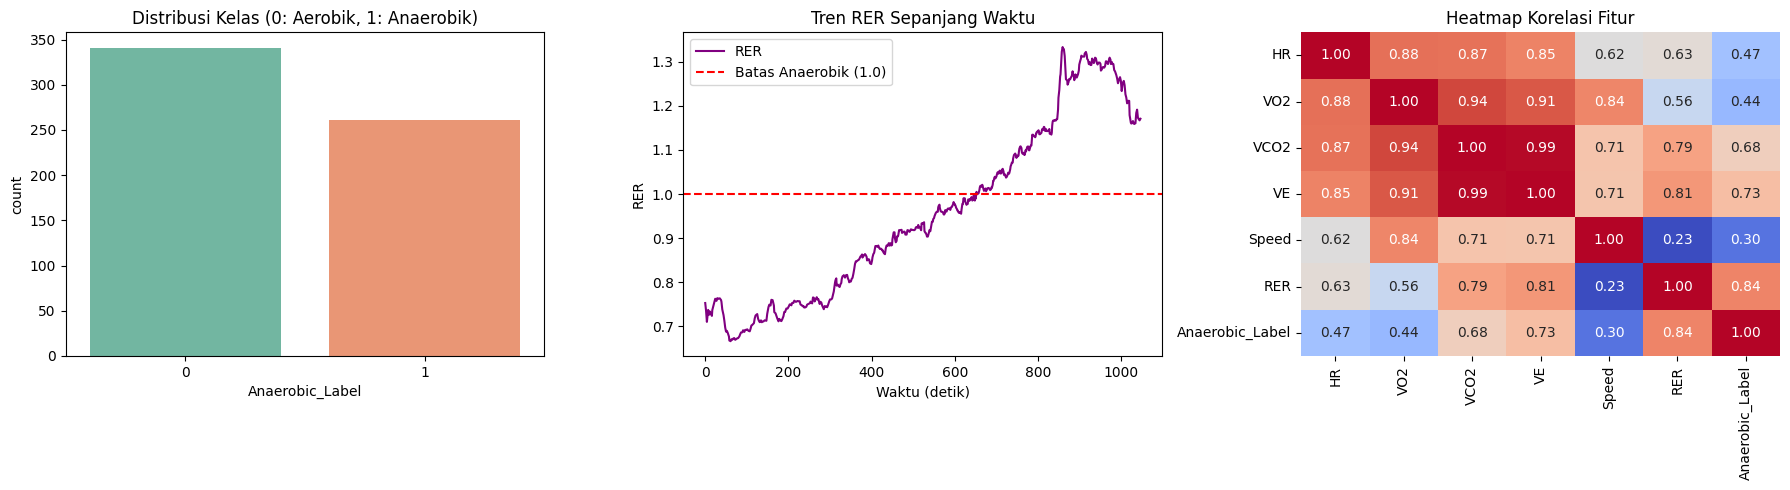

In [5]:
print("Melakukan EDA")

plt.figure(figsize=(18, 5))

# A. Distribusi Kelas Target
plt.subplot(1, 3, 1)
sns.countplot(x='Anaerobic_Label', data=df_subject, palette='Set2')
plt.title('Distribusi Kelas (0: Aerobik, 1: Anaerobik)')

# B. Tren RER terhadap Waktu
plt.subplot(1, 3, 2)
plt.plot(df_subject['time'], df_subject['RER'], color='purple', label='RER')
plt.axhline(y=1.0, color='r', linestyle='--', label='Batas Anaerobik (1.0)')
plt.title('Tren RER Sepanjang Waktu')
plt.xlabel('Waktu (detik)')
plt.ylabel('RER')
plt.legend()

# C. Heatmap Korelasi Fitur
plt.subplot(1, 3, 3)
corr_cols = ['HR', 'VO2', 'VCO2', 'VE', 'Speed', 'RER', 'Anaerobic_Label']
sns.heatmap(df_subject[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", cbar=False)
plt.title('Heatmap Korelasi Fitur')

plt.tight_layout()
plt.show()

# 4. ***ADVANCED FEATURE ENGINEERING & PREPROCESSING***

In [6]:
# Menambahkan Fitur Moving Average (MA) untuk menghaluskan noise sensor (window=3)
df_subject['HR_MA'] = df_subject['HR'].rolling(window=3, min_periods=1).mean()
df_subject['VE_MA'] = df_subject['VE'].rolling(window=3, min_periods=1).mean()

features = ['HR', 'HR_MA', 'VO2', 'VCO2', 'VE', 'VE_MA', 'Speed']
data_X = df_subject[features].values
data_Y = df_subject['Anaerobic_Label'].values

# Normalisasi
scaler = MinMaxScaler(feature_range=(0, 1))
data_X_scaled = scaler.fit_transform(data_X)

# Sliding Window
def create_sequences(X, y, time_steps):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 10
X_seq, y_seq = create_sequences(data_X_scaled, data_Y, time_steps)

# Split Training dan Testing (Sequential, tanpa shuffle)
split_idx = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]

# 5. ***ADVANCED MODEL ARCHITECTURE (Bi-LTSM)***

In [7]:
model = Sequential([
    # Layer Bidirectional LSTM
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(X_train.shape[1], X_train.shape[2])),
    BatchNormalization(),
    Dropout(0.3),
    
    # Layer Bidirectional LSTM kedua
    Bidirectional(LSTM(32, return_sequences=False)),
    BatchNormalization(),
    Dropout(0.3),
    
    # Output Layer
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Callbacks: Pintar dalam mengatur epoch dan learning rate
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1)

print("\nMemulai Training Model Advanced...")
history = model.fit(
    X_train, y_train, 
    epochs=100, # Bisa diset tinggi karena ada EarlyStopping
    batch_size=16, 
    validation_split=0.1, 
    shuffle=False, 
    callbacks=[early_stopping, lr_scheduler],
    verbose=1
)


Memulai Training Model Advanced...
Epoch 1/100


E0000 00:00:1779881016.471335   12466 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1779881016.471730   13504 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1779881016.486461   12466 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
/usr/local/lib/python3.13/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Seque

27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.7788 - loss: 0.6965 - val_accuracy: 0.0000e+00 - val_loss: 1.1495 - learning_rate: 0.0010
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7788 - loss: 0.5687 - val_accuracy: 0.0000e+00 - val_loss: 1.1694 - learning_rate: 0.0010
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7788 - loss: 0.5775 - val_accuracy: 0.0000e+00 - val_loss: 1.2551 - learning_rate: 0.0010
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7741 - loss: 0.5657 - val_accuracy: 0.0000e+00 - val_loss: 1.4224 - learning_rate: 0.0010
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7741 - loss: 0.5512 - val_accuracy: 0.0000e+00 - val_loss: 1.5441 - learning_rate: 0.0010
Epoch 6/100
18/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9982 - loss: 0.1723
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7741 - loss: 0.5368 - 

# 6. ***EVALUASI***


Akurasi Testing (Advanced Model): 0.00%
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step

--- Classification Report ---
               precision    recall  f1-score   support

  Aerobik (0)       0.00      0.00      0.00       0.0
Anaerobik (1)       0.00      0.00      0.00     119.0

     accuracy                           0.00     119.0
    macro avg       0.00      0.00      0.00     119.0
 weighted avg       0.00      0.00      0.00     119.0



/home/theokaitou/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/theokaitou/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/theokaitou/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/

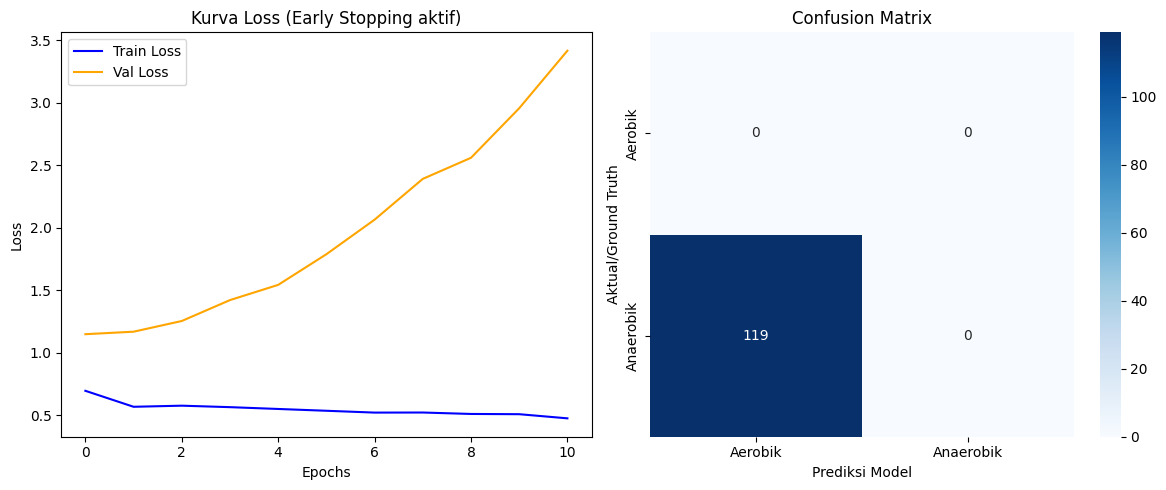

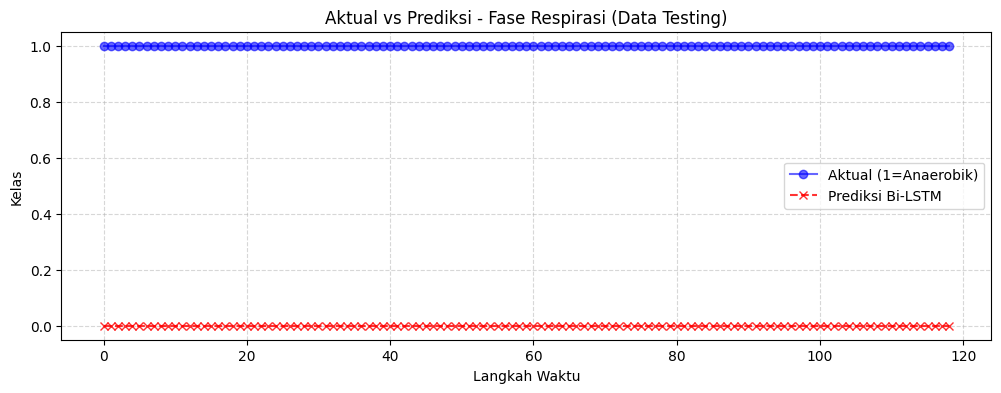

In [8]:
# Evaluasi Akurasi
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nAkurasi Testing (Advanced Model): {test_acc * 100:.2f}%")

# Prediksi untuk Confusion Matrix & Classification Report
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs >= 0.5).astype(int).flatten()

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Aerobik (0)', 'Anaerobik (1)']))

# Visualisasi Loss & Confusion Matrix
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Kurva Loss (Early Stopping aktif)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Confusion Matrix
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Aerobik', 'Anaerobik'], yticklabels=['Aerobik', 'Anaerobik'])
plt.title('Confusion Matrix')
plt.xlabel('Prediksi Model')
plt.ylabel('Aktual/Ground Truth')

plt.tight_layout()
plt.show()

# Grafik Prediksi vs Aktual
plt.figure(figsize=(12, 4))
plt.plot(y_test, label='Aktual (1=Anaerobik)', color='blue', marker='o', alpha=0.6)
plt.plot(y_pred, label='Prediksi Bi-LSTM', color='red', linestyle='--', marker='x', alpha=0.8)
plt.title('Aktual vs Prediksi - Fase Respirasi (Data Testing)')
plt.xlabel('Langkah Waktu')
plt.ylabel('Kelas')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()